# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | bare Python triple loops | sequential timing baseline; its O(N²) cost caps the speedup sweep at N = 2048 |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |
| `GpuV3` | fused FlashAttention-1 forward | one kernel, resident Q tile, online softmax — the N×N matrix never exists |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline, TorchPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

# The two sweep groups. Everything that needs the python-loop CPU baseline
# or a CPU-side profile stops at 2048; GPU-only sweeps run to 32768, the
# last N whose N x N intermediates fit on the card.
CPU_LENS = [2 ** x for x in range(6, 12)]   # 64 .. 2048   (Charts 2, 4: python-loop-capped)
GPU_LENS = [2 ** x for x in range(6, 16)]   # 64 .. 32768  (Charts 3, 5-7)
PROFILE_LENS = [2 ** x for x in range(6, 15)]  # 64 .. 16384 (Charts 1, 9: the
#                  all-PyTorch profile is BLAS-fast, feasible past the loop cap)

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

Two CPU models split the two Stage-1 jobs.

**Profiling — `TorchPipeline`.** For the step-time distribution every stage,
attention included, runs as vectorized PyTorch ops, so the
`torch.profiler.record_function` shares reflect *algorithmic* cost, not
interpreter overhead. Attention is the only $O(N^2 D)$ step in the block;
projections and FFN are $O(N D^2)$, linear in N. Chart 1 shows exactly that
scaling: the attention share starts small at $N = 64$, where the FFN
dominates, crosses the FLOP-count crossover at
$N \approx 5.5D \approx 700$ mid-sweep, and owns the pass long before the top. Chart 2 zooms
into the attention step itself: how its time splits between the two
$O(N^2 D)$ matmuls and the $O(N^2)$ softmax between them.

**Timing baseline — `CpuPipeline`.** The speedup sweep needs a sequential
reference, so there attention runs as bare Python triple loops — no BLAS,
no SIMD, no threads. Its $O(N^2 D)$ interpreter cost (~1.5 min per attention
pass at $N = 2048$) is what caps the CPU-relative sweeps.

In [2]:
# Correctness gate: both CPU models must match torch's SDPA oracle before
# they can serve as profiling / timing references.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    for m in (cpu_model, TorchPipeline().eval()):
        # CpuPipeline: fp64 python floats vs fp32; TorchPipeline: unfused vs fused
        torch.testing.assert_close(m(x), bench.sdpa_reference(m, x),
                                   atol=1e-4, rtol=1e-3)
print("CpuPipeline & TorchPipeline match the torch SDPA oracle")

CpuPipeline & TorchPipeline match the torch SDPA oracle


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:10:05 2186127:2186127 ActivityProfilerController.cpp:455] profiler_st

USDT:2026-08-19 07:10:06 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-19 07:10:06 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-19 07:10:06 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-19 07:10:06 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-19 07:10:07 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-19 07:10:09 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-19 07:10:11 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop


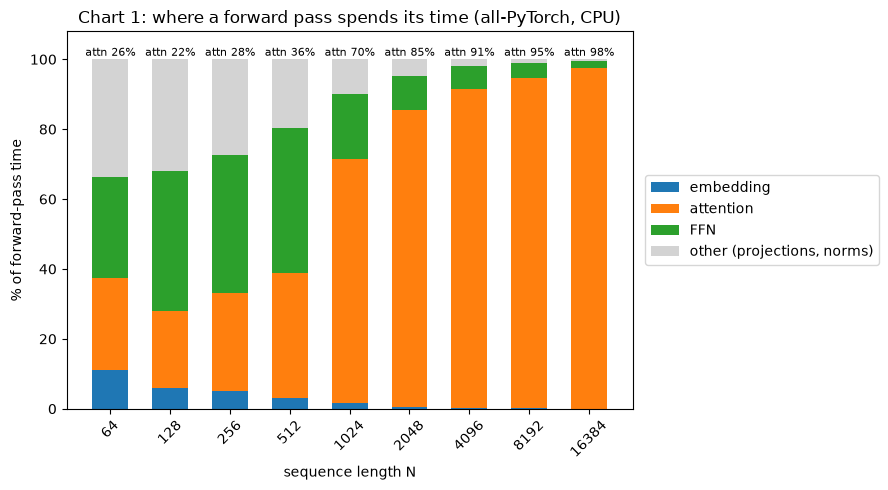

In [3]:
# Chart 1 -- share of forward-pass time per coarse stage (all-PyTorch
# pipeline). One profiled pass per N also yields the attention sub-step
# shares Chart 2 reuses (its CPU_LENS prefix); the sub-steps nest inside 2_attention_total, so
# "other" is computed against the coarse stages only (the profiler's own
# remainder would double-count the nested labels).
import matplotlib.pyplot as plt
import numpy as np

torch_model = TorchPipeline().eval()
pcts = [bench.step_percentages(torch_model, n,
                               steps=bench.STEPS_TOTAL + bench.ATTN_STEPS)
        for n in PROFILE_LENS]

parts = bench.STEPS_TOTAL + ["other"]
names = {"1_embedding": "embedding", "2_attention_total": "attention",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
          "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([100.0 - sum(p[s] for s in bench.STEPS_TOTAL)
                     if part == "other" else p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate the attention share
    ax.text(xi, 101, f"attn {p['2_attention_total']:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("Chart 1: where a forward pass spends its time (all-PyTorch, CPU)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

### Chart 2 — inside the attention step

The same profiled passes, sub-steps normalized within the attention total:
QK$^T$ and the weighted sum are the two $O(N^2 D)$ matmuls; the softmax
between them touches each of the $N^2$ scores only a constant number of
times, so its share stays the small slice the D-factor predicts.

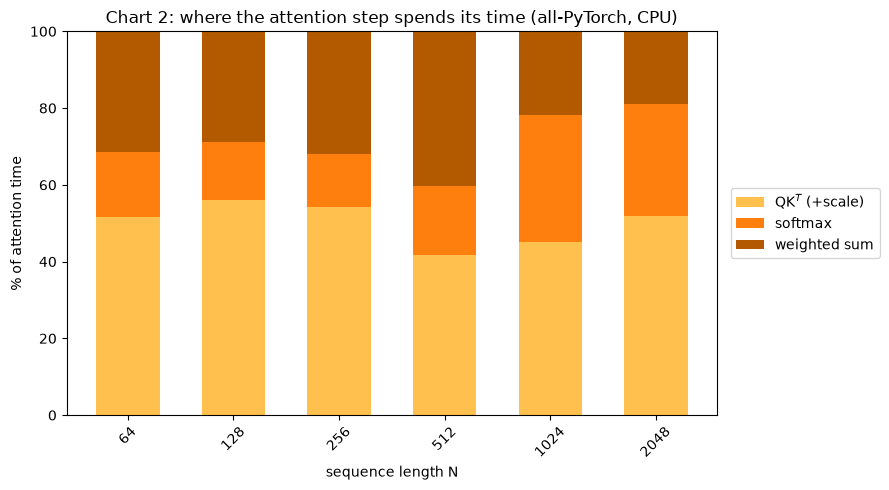

In [4]:
# Chart 2 -- share of *attention* time per sub-step (same profiled passes as
# Chart 1), normalized within the sub-step total so the bars stack to 100%
sub_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
             "2c_value_weighted_sum": "weighted sum"}
sub_colors = {"2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
              "2c_value_weighted_sum": "#b35a00"}
shares = [{s: 100.0 * p[s] / sum(p[t] for t in bench.ATTN_STEPS)
           for s in bench.ATTN_STEPS} for p in pcts[:len(CPU_LENS)]]

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(CPU_LENS))
bottom = np.zeros(len(CPU_LENS))
for s in bench.ATTN_STEPS:
    vals = np.array([sh[s] for sh in shares])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=sub_names[s], color=sub_colors[s])
    bottom += vals

ax.set_xticks(xpos, CPU_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of attention time")
ax.set_ylim(0, 100)
ax.set_title("Chart 2: where the attention step spends its time (all-PyTorch, CPU)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Three versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse; V3 changes the algorithm so the traffic V2 was
economising never exists at all.

**V1 — naive three-launch** (`gpu_v1.py`): `_matmul` (QK$^T$, with the
$1/\sqrt{D}$ scale fused into the epilogue), `_softmax`, `_matmul`
(weights·V) — and every intermediate including the full N×N score matrix
round-trips through global memory. The matmul loads are coalesced (adjacent
threads read adjacent addresses) but nothing is reused, and the softmax
uses one block per row with a coalesced read but still passes over the row
three times (max, sum, write); V2 folds those into one pass.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from
global memory 16× less often; shared arrays are padded to dodge bank
conflicts) and fuses the $1/\sqrt{D}$ scaling into the epilogue.
`_softmax_online` uses one block per row: a running (max, sum) pair
rescaled when the max moves — the log-sum-exp trick — gets both out of
**one** coalesced read of the row.

**V3 — fused FlashAttention-1 forward** (`gpu_v3.py`): the whole step in one
kernel, and the $N \times N$ score matrix never exists in any memory. Each
block stages its 16-row Q tile in shared memory *once* and keeps it resident
while sweeping the K/V blocks — Q traffic drops from $O(N^2 D)$ to $O(N D)$.
At $d_{model} = 128$ the paper's standard layout fits on-chip whole: every
sweep step stages one full-width $[16, D]$ K block and one $[16, D]$ V block
beside the resident Q tile (~26 KB of the 48 KB budget — the $d^2 \ll M$
regime every FlashAttention figure assumes), so there is no chunked staging,
no prefetching, no unrolling, no micro-tiles. Per 16×16 tile: the score tile
$S = QK^T/\sqrt{D}$ is computed entirely from shared memory; then
Algorithm 1 of the FlashAttention paper runs verbatim — the tile's row max
$\tilde{m}$ and sum $\tilde{l}$ merge into the running $(m, l)$, and the
output block is rescaled *and renormalised* on the spot, so it always holds
the exact softmax-weighted sum of every key seen so far. Where V2 economised
the N×N traffic, V3 deletes it — at the price of one rescale-divide per tile.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [5]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV2: matches torch SDPA within 1e-4


GpuV3: matches torch SDPA within 1e-4


## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v, measured
end-to-end: the GPU numbers *include* the CPU→GPU→CPU transfers — the true
cost of swapping a kernel into an otherwise-CPU pipeline. The GPU sweep runs
the powers of two from $2^6$ to $2^{15}$ (64 → 32768, the last N whose N×N
intermediates fit on the card); the CPU column stops at $2^{11}$ = 2048 —
still covering every spec checkpoint (128 / 512 / 2048) — because the
python-loop baseline's $O(N^2 D)$ interpreter cost reaches minutes per pass
there. A calibration pass projects that cost and warns when a sequence
length would not be feasible (cell timeout or RAM).

In [6]:
if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3,
               }
    # end-to-end attention time, CPU<->GPU transfers included; the full GPU
    # sweep serves Chart 5, its CPU_LENS prefix Charts 3 and 4
    gpu_times = bench.bench_attention(classes, GPU_LENS, reps=3)
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # feasibility guard: the baseline is interpreted python with O(N^2 D)
    # cost -- calibrate one pass, project the sweep top against the cell
    # timeout and available RAM
    import os
    cal_ms = bench.attention_ms(cpu_model, 256, reps=1, warmup=False)
    proj_s = cal_ms * (CPU_LENS[-1] / 256) ** 2 / 1e3
    ram = os.sysconf("SC_PHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    need = 2 * CPU_LENS[-1] ** 2 * 32  # scores + weights as python float lists
    if proj_s > 3300 or need > 0.6 * ram:
        print(f"WARNING: N = {CPU_LENS[-1]} may not be feasible on the python "
              f"baseline: projected ~{proj_s / 60:.0f} min per attention pass, "
              f"~{need / 1e9:.1f} GB of {ram / 1e9:.0f} GB RAM")

    # CPU measured last (slowest by far): one plain pass per point -- nothing
    # downstream needs the CPU sub-step split, only the whole-step time
    cpu_ms = [bench.attention_ms(cpu_model, n, reps=1, warmup=False)
              for n in CPU_LENS]

    header = f"{'N':>6} {'CPU python-loop':>18}" + "".join(f"{name:>28}" for name in gpu_times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(GPU_LENS):
        cpu_col = f"{cpu_ms[i]:>15.2f} ms" if i < len(cpu_ms) else f"{'--':>18}"
        print(f"{n:>6} {cpu_col}"
              + "".join(f"{gpu_times[name][i]:>25.2f} ms" for name in gpu_times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green"}

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


     N    CPU python-loop                    V1 naive   V2 tiled + online softmax              V3 flash fused
-------------------------------------------------------------------------------------------------------------
    64           59.17 ms                     1.70 ms                     1.59 ms                     0.91 ms
   128          229.29 ms                     1.60 ms                     1.55 ms                     0.95 ms
   256          970.07 ms                     1.74 ms                     1.65 ms                     1.13 ms
   512         4161.23 ms                     2.13 ms                     1.95 ms                     1.44 ms
  1024        18127.15 ms                     3.28 ms                     2.68 ms                     2.44 ms
  2048        86375.88 ms                     9.36 ms                     5.56 ms                     5.71 ms
  4096                 --                    34.77 ms                    15.91 ms                    14.81 ms
  8192    

## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Device-resident timing with CUDA events: q/k/v already live on the card, so
the timed region is pure kernel work — no CPU→GPU→CPU copy. Chart 3 puts the
two clocks side by side as the transfer-overhead share of the end-to-end
time, $(t_{e2e} - t_{kernel}) / t_{e2e}$ — strictly, everything that is not
kernel: transfers, launch and sync overhead, per-call allocations. This is
the only performance chart where the kernel clock appears; Charts 4–5 stay
end-to-end. Chart 3 involves only the GPU versions — the CPU never enters —
so it sweeps the full GPU range to N = 32768; the same times also supply
the boost-clock denominators of Charts 6–7.

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident) -- GPU-only, full
# range: it feeds Chart 3's transfer decomposition and the boost-clock
# denominators of Charts 6-7
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in GPU_LENS]
              for name, m in kmodels.items()}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(GPU_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: Tesla T4 | 40 SMs



     N                      V1 naive     V2 tiled + online softmax                V3 flash fused   (kernel-only ms)
------------------------------------------------------------------------------------------------
    64                      1.260 ms                      1.202 ms                      0.586 ms
   128                      1.234 ms                      1.165 ms                      0.585 ms
   256                      1.238 ms                      1.162 ms                      0.590 ms
   512                      1.298 ms                      1.186 ms                      0.607 ms
  1024                      1.788 ms                      1.294 ms                      0.982 ms
  2048                      8.067 ms                      3.261 ms                      3.400 ms
  4096                     32.538 ms                     13.633 ms                     13.042 ms
  8192                    147.347 ms                     61.399 ms                     50.556 ms
 16384    

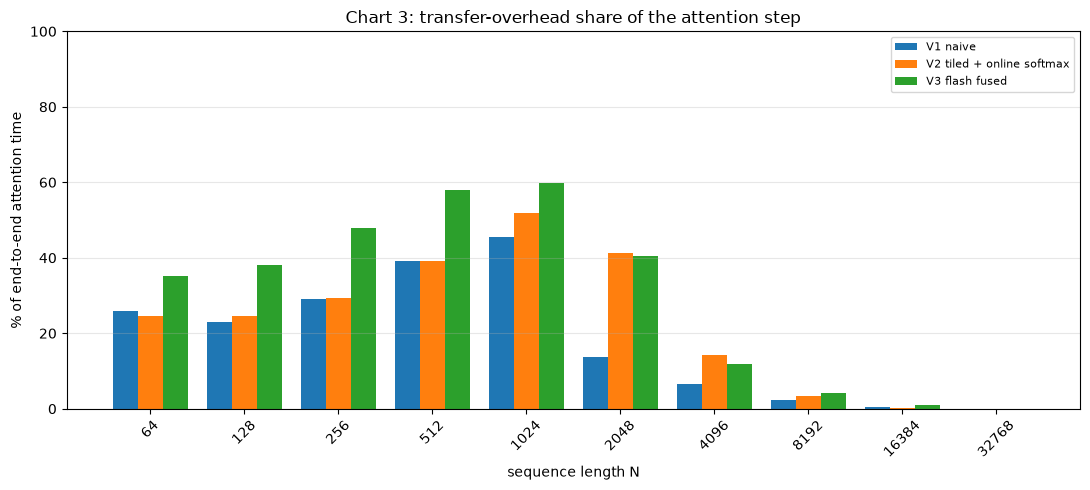

In [8]:
# Chart 3 -- share of the end-to-end attention time spent outside the
# kernels (CPU<->GPU transfers + launch/sync overhead), per GPU version,
# over the full GPU sweep: the fixed overhead dominates small N and the
# O(N^2) kernel work amortizes it away. e2e and kernel come from separate
# sweeps, so large-N shares sit within timing noise of zero (clamped at 0).
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(11, 5))
    xpos = np.arange(len(GPU_LENS))
    w = 0.8 / len(gpu_times)
    offs = (np.arange(len(gpu_times)) - (len(gpu_times) - 1) / 2) * w
    for off, name in zip(offs, gpu_times):
        share = [max(0.0, 100.0 * (e - kt) / e)
                 for e, kt in zip(gpu_times[name], ktimes[name])]
        ax.bar(xpos + off, share, w, color=COLORS[name], label=name)
    ax.set_xticks(xpos, GPU_LENS, rotation=45)
    ax.set_ylim(0, 100)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("% of end-to-end attention time")
    ax.set_title("Chart 3: transfer-overhead share of the attention step")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the transfer-share chart")

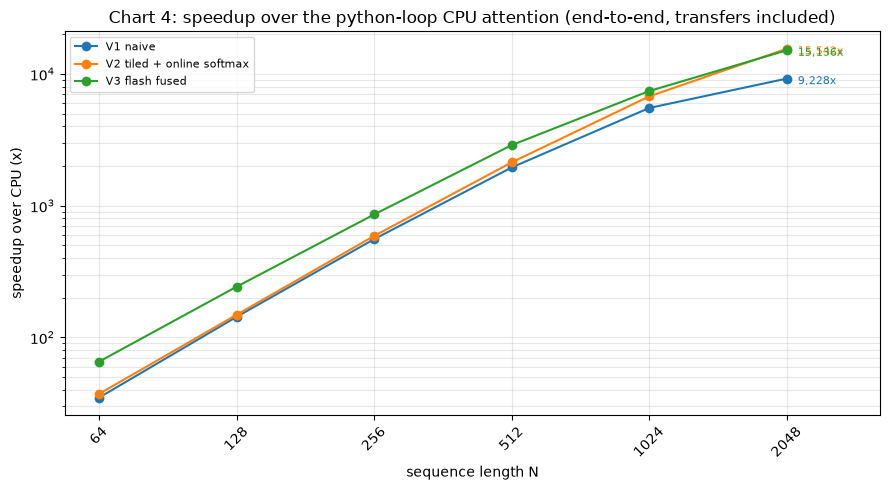

In [9]:
# Chart 4 -- speedup of the whole attention step over the python-loop CPU
# baseline, end-to-end (transfers included). Log-log lines: the sweep spans
# decades, and the vertical gap between curves reads directly as the ratio
# between versions at each N
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(9, 5))
    for name in gpu_times:
        sp = [c / g for c, g in zip(cpu_ms, gpu_times[name][:len(CPU_LENS)])]
        ax.plot(CPU_LENS, sp, marker="o", color=COLORS[name], label=name)
        ax.annotate(f"{sp[-1]:,.0f}x", (CPU_LENS[-1], sp[-1]),
                    textcoords="offset points", xytext=(8, -4), fontsize=8,
                    color=COLORS[name])
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(CPU_LENS, CPU_LENS, rotation=45)
    ax.set_xlim(right=CPU_LENS[-1] * 1.6)  # room for the end-point labels
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("speedup over CPU (x)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title("Chart 4: speedup over the python-loop CPU attention "
                 "(end-to-end, transfers included)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the speedup chart")

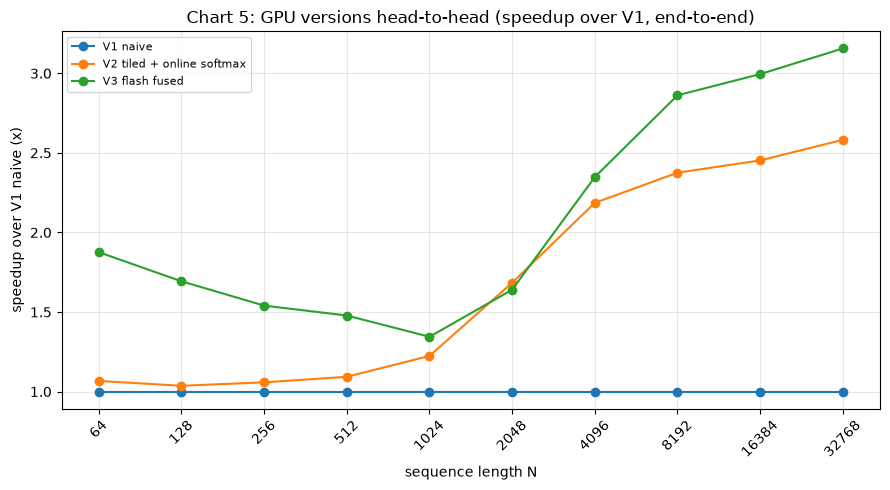

In [10]:
# Chart 5 -- the three GPU rungs head-to-head, end-to-end (transfers
# included), swept past the CPU cap to N = 32768 as speedup over V1
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, ts in gpu_times.items():
        ax.plot(GPU_LENS, [v1 / t for v1, t in zip(gpu_times["V1 naive"], ts)],
                marker="o", color=COLORS[name], label=name)
    ax.set_xscale("log", base=2)
    ax.set_xticks(GPU_LENS, GPU_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("speedup over V1 naive (x)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title("Chart 5: GPU versions head-to-head (speedup over V1, end-to-end)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the head-to-head chart")

## Measured kernel performance and hardware utilization

Ops and bytes from Nsight Compute (SASS thread-instruction counters for
fp32 FLOPs — fadd + fmul + 2·ffma; `dram__bytes.sum` for every transaction
crossing the DRAM boundary, refetches included — a one-off root-gated
collection cached in `dram_profile.json`), time from the boost-clock
CUDA-event kernel sweep. The pairing matters: ncu locks the GPU to base
clocks, so its own durations run ~2.3× the event sweep — the counts are
clock-independent and ride on the honest time. These analyses are GPU-only
and sweep to $N = 2^{15}$, the last size where V1/V2's N×N intermediates
still fit on the card.

Chart 6 shows the achieved rates as *utilization* of each ceiling — % of
the fp32 compute peak, % of the DRAM bandwidth peak. The raw counts and
their floor ratios (the $4N^2D$ FLOP floor; the compulsory Q, K, V + out
byte floor) are in the table below it.

In [11]:
# Measured ncu counters -- load (or one-off collect) dram_profile.json for
# Charts 6-7: per (version, N) DRAM bytes, base-clock kernel time, fp32 FLOPs
if cuda.is_available():
    import json, os, subprocess, sys
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    if not prof_path.exists():  # counters are root-gated: one-off sudo step
        cmd = ([] if os.geteuid() == 0 else ["sudo", "-n"]) + \
              [sys.executable, "src/dram_profile.py", "collect"]
        try:
            subprocess.run(cmd, check=True)
        except (subprocess.CalledProcessError, FileNotFoundError, PermissionError):
            pass

    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        prof = {}
        print("no usable dram_profile.json here -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        print(f"dram_profile.json: {sorted(prof)} x "
              f"N = {prof['v1'][0]['n']} .. {prof['v1'][-1]['n']}")
else:
    prof = {}
    print("No CUDA device -- skipping the measured-counter analyses")

dram_profile.json: ['v1', 'v2', 'v3'] x N = 64 .. 32768


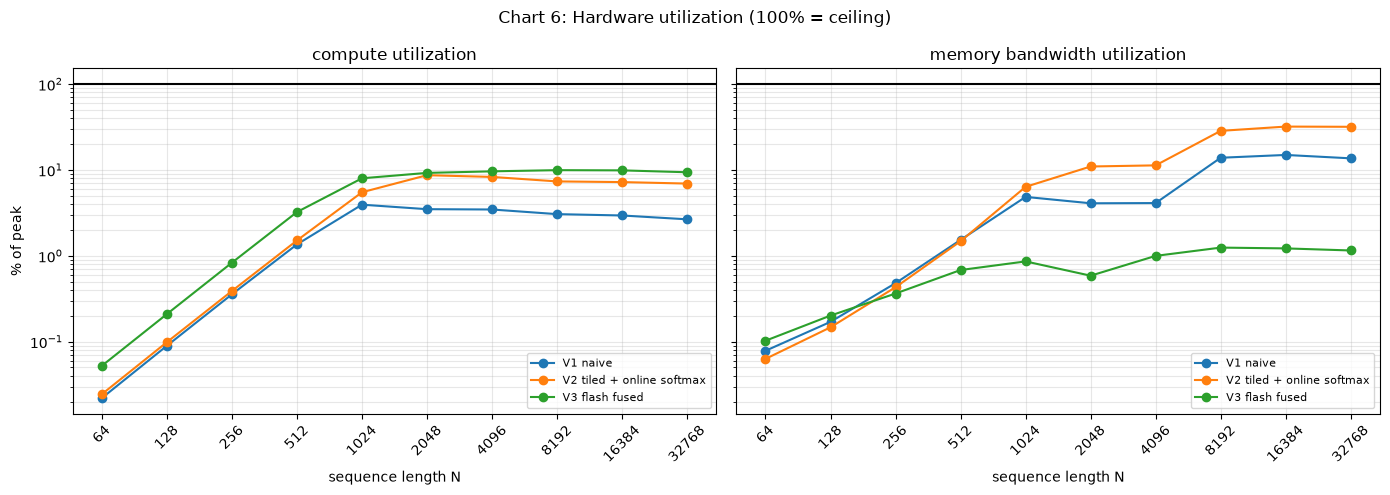

                   version      N     GFLOP  floor x  GB moved  floor x  compute %  bandwidth %


                  V1 naive  32768     586.3   1.066x    118.24  1761.9x       2.7%        13.6%


 V2 tiled + online softmax  32768     586.6   1.067x    105.70  1575.0x       6.9%        31.8%


            V3 flash fused  32768     653.9   1.189x      3.16    47.0x       9.4%         1.2%


In [12]:
# Chart 6: Hardware utilization -- measured rates (ncu counts over the
# boost-clock CUDA-event kernel time) as % of each ceiling
if cuda.is_available() and prof:
    specs = bench.gpu_specs()
    tmaps = {k: dict(zip(GPU_LENS, ktimes[pnames[k]])) for k in prof}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for key, rows in prof.items():
        name = pnames[key]
        ns = [r["n"] for r in rows]
        cu = [100 * r["flops"] / (tmaps[key][r["n"]] / 1e3) / 1e12 / specs["tflops"]
              for r in rows]
        bu = [100 * r["dram_bytes"] / (tmaps[key][r["n"]] / 1e3) / 1e9 / specs["bw_gbs"]
              for r in rows]
        axes[0].plot(ns, cu, marker="o", color=COLORS[name], label=name)
        axes[1].plot(ns, bu, marker="o", color=COLORS[name], label=name)
    axes[0].set_title("compute utilization")
    axes[1].set_title("memory bandwidth utilization")
    axes[0].set_ylabel("% of peak")
    for ax in axes:
        ax.axhline(100.0, color="k", lw=1.5)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(GPU_LENS, GPU_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize=8)
    plt.suptitle("Chart 6: Hardware utilization (100% = ceiling)")
    plt.tight_layout()
    plt.show()

    print(f"{'version':>26} {'N':>6} {'GFLOP':>9} {'floor x':>8} "
          f"{'GB moved':>9} {'floor x':>8} {'compute %':>10} {'bandwidth %':>12}")
    for key, rows in prof.items():
        r = rows[-1]
        t_s = tmaps[key][r["n"]] / 1e3
        ff = bench.attention_flops(cpu_model, r["n"])
        fb = bench.attention_bytes(cpu_model, r["n"])
        cu = 100 * r["flops"] / t_s / 1e12 / specs["tflops"]
        bu = 100 * r["dram_bytes"] / t_s / 1e9 / specs["bw_gbs"]
        print(f"{pnames[key]:>26} {r['n']:>6} {r['flops'] / 1e9:>9.1f} "
              f"{r['flops'] / ff:>7.3f}x {r['dram_bytes'] / 1e9:>9.2f} "
              f"{r['dram_bytes'] / fb:>7.1f}x {cu:>9.1f}% {bu:>11.1f}%")
else:
    print("No measured counters -- skipping the utilization chart")

## Arithmetic intensity — where each kernel lives on the roofline

Arithmetic intensity (AI) is FLOPs per DRAM byte — here *measured*, from the
same counters: executed fp32 ops over measured DRAM traffic. The ridge
point (peak FLOP/s ÷ peak bandwidth, ~25 FLOP/byte on the T4) divides the
regimes: above it a kernel could saturate compute before the bus; below it
the bus caps it first. The dotted line is the *algorithmic* AI — floor
FLOPs over compulsory bytes, $4N^2D / 16ND = N/4$ — what a perfect
implementation would achieve.

The gap between dotted and measured is each implementation's traffic waste:
V1 and V2 collapse from an algorithmic N/4 to a measured ~4 FLOP/byte —
every DRAM byte they move supports only a few operations (the N×N
round-trips and panel re-streams) — and V1 keeps falling, to 1.4 by
N = 32768, as its re-reads outgrow the L2 entirely: it ends the sweep
genuinely memory-bound. V3's
fusion keeps its measured AI two orders of magnitude higher and safely on
the compute side — the roofline's way of saying the bus is not its
problem, shared memory and occupancy are.

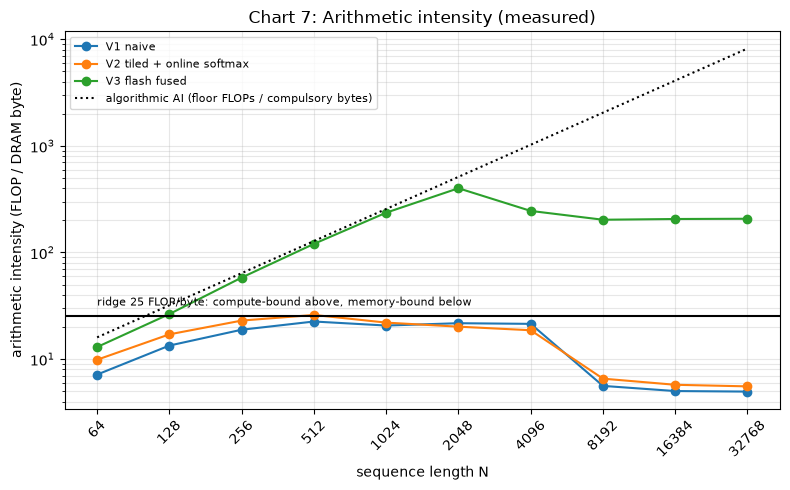

In [13]:
# Chart 7: Arithmetic intensity -- measured FLOPs per measured DRAM byte,
# vs the algorithmic AI (floor FLOPs / compulsory bytes = N/4) and the ridge
if cuda.is_available() and prof:
    specs = bench.gpu_specs()
    fig, ax = plt.subplots(figsize=(8, 5))
    for key, rows in prof.items():
        name = pnames[key]
        ax.plot([r["n"] for r in rows],
                [r["flops"] / r["dram_bytes"] for r in rows],
                marker="o", color=COLORS[name], label=name)
    alg = [bench.attention_flops(cpu_model, n) / bench.attention_bytes(cpu_model, n)
           for n in GPU_LENS]
    ax.plot(GPU_LENS, alg, "k:", label="algorithmic AI (floor FLOPs / compulsory bytes)")
    ridge = specs["tflops"] * 1e12 / (specs["bw_gbs"] * 1e9)
    ax.axhline(ridge, color="k", lw=1.5)
    ax.text(GPU_LENS[0], ridge * 1.25,
            f"ridge {ridge:.0f} FLOP/byte: compute-bound above, memory-bound below",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(GPU_LENS, GPU_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("arithmetic intensity (FLOP / DRAM byte)")
    ax.set_title("Chart 7: Arithmetic intensity (measured)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No measured counters -- skipping the arithmetic-intensity chart")

## Memory footprint — the O(N²) wall

Traffic explains speed; footprint decides feasibility. The unfused versions
materialise the N×N score and weight matrices — $2N^2 \cdot 4$ bytes beyond
the inputs, quadrupling with every doubling of N — while V3 streams tiles
and allocates only the [N, D] output. The sweep runs past the analyses
above until the quadratic versions stop fitting on the card: the wall is
measured (torch allocator high-water mark, OOM caught), not modelled.

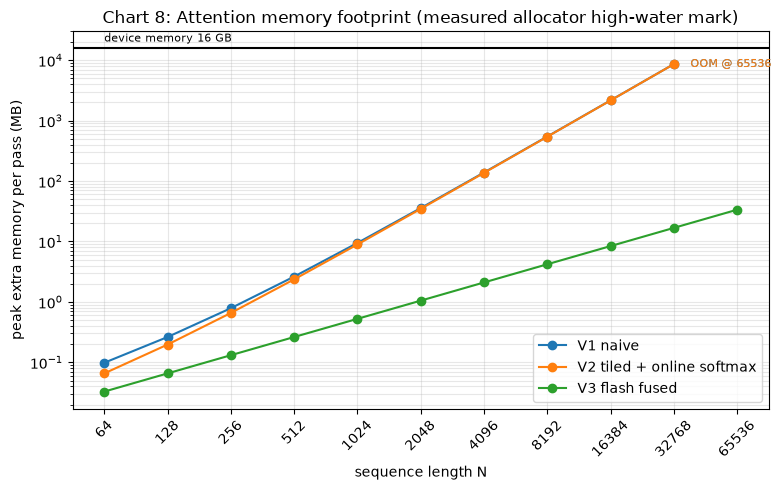

                  V1 naive: fits to N = 32768, OOM at N = 65536
 V2 tiled + online softmax: fits to N = 32768, OOM at N = 65536
            V3 flash fused: fits to N = 65536


In [14]:
# Chart 8: peak extra GPU memory of one attention pass, swept until the
# O(N^2) versions hit the card's capacity. None (OOM) ends a line.
if cuda.is_available():
    FOOT_LENS = [2 ** x for x in range(6, 17)]  # 64 .. 65536
    foot_models = {"V1 naive": GpuV1(), "V2 tiled + online softmax": GpuV2(),
                   "V3 flash fused": GpuV3()}
    foot = {name: [] for name in foot_models}
    for n in FOOT_LENS:
        for name, m in foot_models.items():
            foot[name].append(bench.attention_peak_extra_bytes(m, n))
        torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, vals in foot.items():
        pts = [(n, b) for n, b in zip(FOOT_LENS, vals) if b is not None]
        xs, ys = [p[0] for p in pts], [p[1] / 1e6 for p in pts]
        ax.plot(xs, ys, marker="o", color=COLORS[name], label=name)
        if len(pts) < len(FOOT_LENS):  # line ends where the alloc stopped fitting
            ax.text(xs[-1] * 1.2, ys[-1], f"OOM @ {FOOT_LENS[len(pts)]}",
                    color=COLORS[name], fontsize=8, va="center")
    total = torch.cuda.get_device_properties(0).total_memory
    ax.axhline(total / 1e6, color="k", lw=1.5)
    ax.text(FOOT_LENS[0], total / 1e6 * 1.3, f"device memory {total / 1e9:.0f} GB",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(FOOT_LENS, FOOT_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("peak extra memory per pass (MB)")
    ax.set_title("Chart 8: Attention memory footprint (measured allocator high-water mark)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for name, vals in foot.items():
        fit = sum(b is not None for b in vals)
        print(f"{name:>26}: fits to N = {FOOT_LENS[fit - 1]}"
              + ("" if fit == len(FOOT_LENS) else f", OOM at N = {FOOT_LENS[fit]}"))
else:
    print("No CUDA device -- skipping the footprint sweep")

## Chart 9 — the SOTA yardstick

Chart 1's stage shares, closing the loop: attention runs as torch's fused
SDPA kernel on the GPU while every other stage stays in PyTorch on the
CPU — the same partial-GPU pattern (and the same transfer cost) as V1–V3,
so the bands are directly comparable. Torch's FlashAttention-2 backend
requires sm80+ and fp16/bf16; this project is fp32 on a T4 (sm75), so the
backend probe lands on the memory-efficient kernel — the same fused
online-softmax family (FlashAttention-1-style tiling) and the strongest
attention torch offers for this card and dtype. The title records the
backend that actually ran.

SOTA attention backend: torch SDPA memory-efficient (flash needs sm80+ & fp16)


/tmp/ipykernel_2186127/1710693398.py:24: UserWarning: Memory efficient kernel not used because: (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:999.)
  F.scaled_dot_product_attention(probe, probe, probe)
/tmp/ipykernel_2186127/1710693398.py:24: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/sdp_utils_cpp.h:552.)
  F.scaled_dot_product_attention(probe, probe, probe)
/tmp/ipykernel_2186127/1710693398.py:24: UserWarning: Flash attention kernel not used because: (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:1001.)
  F.scaled_dot_product_attention(probe, probe, probe)
/tmp/ipykernel_2186127/1710693398.py:24: UserWarning: Flash attention only supports gpu architectures in the range [sm80, sm121]. Attempting to run on a sm 7.5 gpu. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:342.)
  F.

USDT:2026-08-19 07:14:16 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-19 07:14:16 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:14:16 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-19 07:14:16 2186127:2186127 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-19 07:14:16 2186127:2186127 ActivityProfilerController.cpp:455] profiler_stop


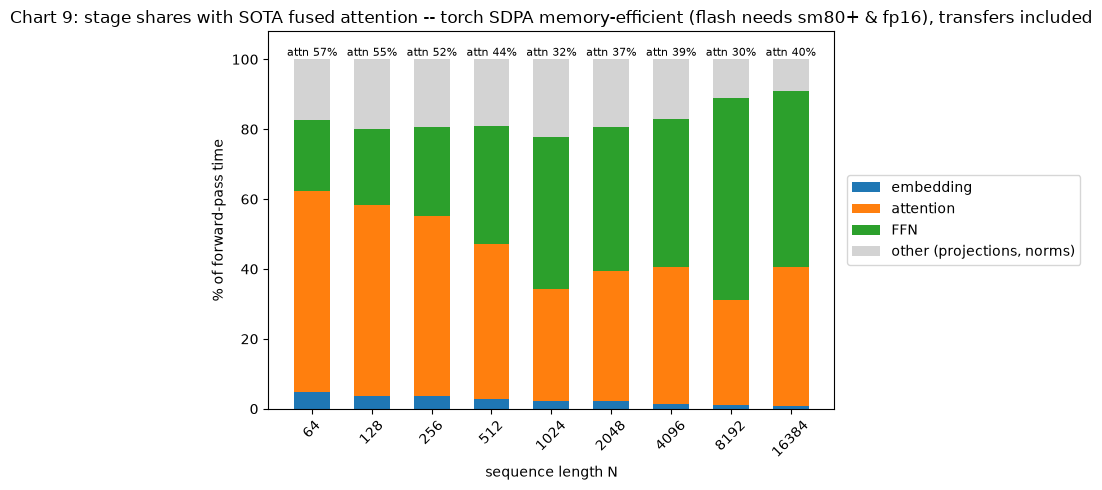

In [15]:
# Chart 9 -- Chart 1's stage shares with the attention step swapped for the
# state-of-the-art fused attention: torch SDPA on the GPU, every other stage
# unchanged in PyTorch on the CPU (the same partial-GPU pattern as V1-V3, so
# the attention band includes the CPU<->GPU transfers). The backend is
# probed at the real (N, D) shape: torch's FlashAttention-2 kernel needs
# sm80+ and fp16/bf16, so on the fp32 T4 (sm75) the applicable fused kernel
# is the memory-efficient backend -- the same tiled online-softmax family
# (FlashAttention-1-style). The title notes which backend actually ran.
if cuda.is_available():
    import torch.nn.functional as F
    from abstract import TransformerBase
    from torch.nn.attention import SDPBackend, sdpa_kernel

    d_model = cpu_model.embedding.embedding_dim
    probe = torch.zeros(1, 1, 64, d_model, device="cuda")  # (B, H, N, D): fused
    # kernels need 4-D; one D-wide head, the same math as every pipeline
    for backend, blabel in [
            (SDPBackend.FLASH_ATTENTION, "flash (FlashAttention-2)"),
            (SDPBackend.EFFICIENT_ATTENTION,
             "memory-efficient (flash needs sm80+ & fp16)"),
            (SDPBackend.MATH, "math (no fused kernel on this card)")]:
        try:
            with sdpa_kernel([backend]):
                F.scaled_dot_product_attention(probe, probe, probe)
            break
        except RuntimeError:
            continue
    print(f"SOTA attention backend: torch SDPA {blabel}")

    class SotaPipeline(TransformerBase):
        """Attention = torch SDPA on the GPU; every other stage stays on CPU."""

        def attention(self, q, k, v):
            out = torch.empty_like(q)
            for b in range(q.shape[0]):
                with sdpa_kernel([backend]):
                    res = F.scaled_dot_product_attention(
                        q[b].detach().contiguous().cuda()[None, None],
                        k[b].detach().contiguous().cuda()[None, None],
                        v[b].detach().contiguous().cuda()[None, None])[0, 0]
                torch.cuda.synchronize()
                out[b] = res.cpu()
            return out

    spcts = [bench.step_percentages(SotaPipeline().eval(), n,
                                    steps=bench.STEPS_TOTAL)
             for n in PROFILE_LENS]

    fig, ax = plt.subplots(figsize=(9, 5))
    xpos = np.arange(len(PROFILE_LENS))
    bottom = np.zeros(len(PROFILE_LENS))
    for part in parts:  # Chart 1's stages and colors
        vals = np.array([100.0 - sum(p[s] for s in bench.STEPS_TOTAL)
                         if part == "other" else p[part] for p in spcts])
        ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
        bottom += vals
    for xi, p in zip(xpos, spcts):
        ax.text(xi, 101, f"attn {p['2_attention_total']:.0f}%", ha="center", fontsize=8)
    ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("% of forward-pass time")
    ax.set_ylim(0, 108)
    ax.set_title("Chart 9: stage shares with SOTA fused attention -- torch "
                 f"SDPA {blabel}, transfers included")
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the SOTA-attention profile")

## Conclusion

Attention dominates the forward pass past N≈700 (Chart 1) and is worth
replacing on its own. Doing so takes N = 2048 from ~1.4 min on the naive
CPU loop to 5.6 ms end-to-end with V2/V3 (~1.5×10⁴×).

The ladder is a memory story: V1 and V2 both materialise the N×N score
matrix, so at N = 32768 they move 118/106 GB per pass and OOM by
N = 65536; V3 fuses everything into one kernel and never creates that
matrix, moving only 3.2 GB and scaling to N = 65536 and beyond
(Charts 6–8). At d = 128 — the paper's assumed regime, where Q/K/V
tiles fit on-chip whole — that fusion wins outright with no extra
engineering: V3 is fastest from N = 4096 up, 3.2× over V1 (Chart 5).

Torch's fused SDPA still dwarfs all three (Chart 9): fusion has to be
hand-built into the kernel, not composed from library calls, and
production kernels bring far more than a numba scalar loop can express.
